# mmraz-qwen3-32b-probe-artifact-steering-question-options-answer-plots

Small plotting notebook for the saved Qwen3-32B probe-artifact steering runs.

It:
- finds the latest compatible Qwen3-32B steering run by default,
- loads the saved steering summary, config, and partial checkpoints,
- replots the main heatmap metrics used in the Qwen3-4B steering plots notebook, and
- saves the replotted figures under a `replots_from_notebook/` subdirectory inside the selected run folder.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams['figure.dpi'] = 130

RUN_DIR_OVERRIDE = globals().get('RUN_DIR_OVERRIDE', None)


def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists() and (candidate / 'results').exists():
            return candidate
    raise RuntimeError('Could not locate the repository root from the current working directory.')


def resolve_run_bundle(run_dir: Path):
    summary_candidates = sorted(run_dir.glob('mmraz_qwen3_32b_probe_artifact_steering_question_options_answer_summary_*.csv'))
    if not summary_candidates:
        raise FileNotFoundError(f'No steering summary found under: {run_dir}')
    config_candidates = sorted(run_dir.glob('mmraz_qwen3_32b_probe_artifact_steering_question_options_answer_config_*.json'))
    artifact_index_candidates = sorted(run_dir.glob('mmraz_qwen3_32b_probe_artifact_steering_question_options_answer_artifacts_*.csv'))
    return {
        'summary_path': summary_candidates[-1],
        'config_path': config_candidates[-1] if config_candidates else None,
        'artifact_index_path': artifact_index_candidates[-1] if artifact_index_candidates else None,
        'partial_dir': run_dir / 'partial',
    }


def find_latest_run_bundle(search_roots):
    candidates = []
    for base_root in search_roots:
        if not base_root.exists():
            continue
        for run_dir in sorted(path for path in base_root.iterdir() if path.is_dir()):
            try:
                bundle = resolve_run_bundle(run_dir)
            except FileNotFoundError:
                continue
            summary_mtime = bundle['summary_path'].stat().st_mtime
            candidates.append((summary_mtime, run_dir, bundle))
    if not candidates:
        return None
    _, run_dir, bundle = sorted(candidates, key=lambda item: (item[0], str(item[1])))[-1]
    return run_dir, bundle


ROOT = find_repo_root(Path.cwd())
SEARCH_ROOTS = [
    ROOT / 'results' / 'qwen3_32b' / 'probe_artifact_steering_question_options_answer_vast',
    ROOT / 'results' / 'qwen3_32b' / 'probe_artifact_steering_question_options_answer_colab',
    ROOT / 'results' / 'qwen3_32b' / '_validation_probe_artifact_steering',
]

RUN_AVAILABLE = False
RUN_DIR = None
bundle = None
config = {}

if RUN_DIR_OVERRIDE is not None:
    RUN_DIR = Path(RUN_DIR_OVERRIDE).expanduser().resolve()
    bundle = resolve_run_bundle(RUN_DIR)
    RUN_AVAILABLE = True
else:
    latest = find_latest_run_bundle(SEARCH_ROOTS)
    if latest is not None:
        RUN_DIR, bundle = latest
        RUN_AVAILABLE = True

if RUN_AVAILABLE:
    SUMMARY_PATH = bundle['summary_path']
    CONFIG_PATH = bundle['config_path']
    ARTIFACT_INDEX_PATH = bundle['artifact_index_path']
    PARTIAL_DIR = bundle['partial_dir']
    PLOT_ROOT = RUN_DIR / 'replots_from_notebook'
    PLOT_ROOT.mkdir(parents=True, exist_ok=True)
    if CONFIG_PATH is not None and CONFIG_PATH.exists():
        config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
    run_id = str(config.get('run_id', RUN_DIR.name))
    print('Repo root          :', ROOT)
    print('Selected run       :', RUN_DIR.name)
    print('Run ID             :', run_id)
    print('Top-level summary  :', SUMMARY_PATH)
    print('Config path        :', CONFIG_PATH)
    print('Partial dir exists :', PARTIAL_DIR.exists())
    print('Plot root          :', PLOT_ROOT)
    if ARTIFACT_INDEX_PATH is not None:
        print('Artifact index     :', ARTIFACT_INDEX_PATH)
else:
    print('No compatible Qwen3-32B steering run found under any of:')
    for root in SEARCH_ROOTS:
        print(' -', root)
    print('Run the steering script first, or set RUN_DIR_OVERRIDE to a specific run directory.')


Repo root          : /Users/michalmraz/code/spar-ai/temporal-awareness
Selected run       : 20260410-102655
Run ID             : 20260410-102655
Top-level summary  : /Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen3_32b/probe_artifact_steering_question_options_answer_vast/20260410-102655/mmraz_qwen3_32b_probe_artifact_steering_question_options_answer_summary_20260410-102655.csv
Config path        : None
Partial dir exists : True
Plot root          : /Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen3_32b/probe_artifact_steering_question_options_answer_vast/20260410-102655/replots_from_notebook


In [2]:
def load_summary_bundle(summary_path: Path, partial_dir: Path) -> pd.DataFrame:
    frames = [pd.read_csv(summary_path)]
    if partial_dir.exists():
        for partial_path in sorted(partial_dir.glob('*_summary.csv')):
            frames.append(pd.read_csv(partial_path))
    summary_df = pd.concat(frames, ignore_index=True, sort=False)
    dedup_cols = ['dataset', 'probe_variant', 'condition', 'layer', 'strength', 'signed_strength']
    summary_df = summary_df.drop_duplicates(subset=dedup_cols, keep='first').reset_index(drop=True)

    numeric_cols = [
        'layer', 'strength', 'signed_strength', 'raw_vector_norm', 'steering_vector_norm',
        'baseline_prop_choose_long_term', 'baseline_prop_choose_immediate',
        'baseline_prop_choose_long_term_no_fallback', 'baseline_prop_choose_immediate_no_fallback',
        'baseline_mean_long_minus_immediate_avg_logprob', 'baseline_prop_logprob_prefers_long_term',
        'delta_long_term_vs_baseline', 'delta_immediate_vs_baseline',
        'delta_long_term_vs_baseline_no_fallback', 'delta_immediate_vs_baseline_no_fallback',
        'delta_long_minus_immediate_avg_logprob_vs_baseline', 'delta_prop_logprob_prefers_long_term_vs_baseline',
        'steering_success', 'steering_success_no_fallback', 'n_prompts', 'n_no_fallback_prompts',
        'prop_choose_long_term', 'prop_choose_immediate',
        'prop_choose_long_term_no_fallback', 'prop_choose_immediate_no_fallback',
        'fallback_rate', 'direct_parse_rate',
        'mean_long_minus_immediate_avg_logprob', 'mean_long_minus_immediate_sum_logprob',
        'prop_logprob_prefers_long_term',
    ]
    for col in numeric_cols:
        if col in summary_df.columns:
            summary_df[col] = pd.to_numeric(summary_df[col], errors='coerce')
    return summary_df


def resolve_heatmap_range(matrix, default_vmin, default_vmax, mode='fixed'):
    if mode == 'fixed':
        return default_vmin, default_vmax
    finite_vals = matrix[np.isfinite(matrix)]
    if finite_vals.size == 0:
        return default_vmin, default_vmax
    vmin = float(np.nanmin(finite_vals))
    vmax = float(np.nanmax(finite_vals))
    if np.isclose(vmin, vmax):
        pad = 1e-6 if np.isclose(vmin, 0.0) else max(abs(vmin) * 0.01, 1e-6)
        vmin -= pad
        vmax += pad
    return vmin, vmax


def build_signed_strength_pivot(summary_df: pd.DataFrame, dataset_name: str, metric_col: str, signed_strength_order, layer_order) -> pd.DataFrame:
    baseline_row = summary_df.loc[
        (summary_df['dataset'] == dataset_name)
        & (summary_df['condition'] == 'baseline')
    ]
    baseline_value = None if baseline_row.empty else baseline_row.iloc[0].get(metric_col)

    d = summary_df.loc[
        (summary_df['dataset'] == dataset_name)
        & (summary_df['condition'] != 'baseline')
        & (summary_df['probe_variant'] != 'baseline')
        & (summary_df['layer'] >= 0)
    ].copy()
    d = d.groupby(['signed_strength', 'layer'], as_index=False)[metric_col].mean()
    pivot = d.pivot(index='signed_strength', columns='layer', values=metric_col)
    pivot = pivot.reindex(index=signed_strength_order, columns=layer_order)

    if baseline_value is not None and not pd.isna(baseline_value):
        pivot.loc[0.0, :] = baseline_value
        pivot = pivot.reindex(index=signed_strength_order, columns=layer_order)
    return pivot


def draw_steering_heatmap(ax, matrix, title, x_labels, y_labels, vmin=0.0, vmax=1.0, cmap='coolwarm', range_mode='fixed'):
    vmin, vmax = resolve_heatmap_range(matrix, vmin, vmax, mode=range_mode)
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color='black')
    im = ax.imshow(matrix, aspect='auto', origin='lower', vmin=vmin, vmax=vmax, cmap=cmap_obj)
    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels([str(label) for label in x_labels])
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_yticklabels([f'{label:g}' for label in y_labels])
    ax.set_xlabel('Layer')
    ax.set_ylabel('Signed strength')
    ax.set_title(title)
    midpoint = float((vmin + vmax) / 2.0) if np.isfinite(vmin) and np.isfinite(vmax) else 0.0
    for row_idx in range(matrix.shape[0]):
        for col_idx in range(matrix.shape[1]):
            value = matrix[row_idx, col_idx]
            text = 'nan' if np.isnan(value) else f'{value:.2f}'
            text_color = 'white' if np.isnan(value) or value < midpoint else 'black'
            ax.text(col_idx, row_idx, text, ha='center', va='center', fontsize=8, color=text_color)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


def plot_metric_grid(summary_df, dataset_order, layer_order, signed_strength_order, dataset_labels, metric_col, figure_title, output_name, cmap, vmin, vmax, range_mode='fixed'):
    fig, axes = plt.subplots(1, len(dataset_order), figsize=(7.5 * len(dataset_order), 5.5), constrained_layout=True, squeeze=False)
    axes = axes[0]
    for ax, dataset_name in zip(axes, dataset_order):
        pivot = build_signed_strength_pivot(summary_df, dataset_name, metric_col, signed_strength_order, layer_order)
        draw_steering_heatmap(
            ax,
            pivot.to_numpy(dtype=float),
            dataset_labels.get(dataset_name, dataset_name.replace('_', ' ')),
            layer_order,
            signed_strength_order,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            range_mode=range_mode,
        )
    fig.suptitle(figure_title, y=1.03)
    output_path = PLOT_ROOT / output_name
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    display(fig)
    plt.close(fig)
    return output_path


In [3]:
if not RUN_AVAILABLE:
    print('Skipping steering summary load because no compatible run was found.')
else:
    summary_df = load_summary_bundle(SUMMARY_PATH, PARTIAL_DIR)
    dataset_order = list((config.get('evaluation_datasets') or {}).keys())
    if not dataset_order:
        dataset_order = sorted(summary_df['dataset'].dropna().astype(str).unique().tolist())
    layer_order = [int(value) for value in config.get('layers_to_test', [])] or sorted(
        value for value in summary_df['layer'].dropna().astype(int).unique().tolist() if value >= 0
    )
    strength_order = [float(value) for value in config.get('strengths', [])] or sorted(
        value for value in summary_df['strength'].dropna().astype(float).unique().tolist() if value > 0
    )
    signed_strength_order = [float(value) for value in config.get('signed_strengths', [])]
    if not signed_strength_order:
        signed_strength_order = sorted(set([-value for value in strength_order] + [0.0] + strength_order))
    dataset_labels = {name: name.replace('_', ' ') for name in dataset_order}

    baseline_df = summary_df.loc[summary_df['condition'] == 'baseline'].copy()
    steered_df = summary_df.loc[summary_df['condition'] != 'baseline'].copy()

    expected_rows = []
    expected_signed_strengths = [value for value in signed_strength_order if value != 0]
    expected_points = len(layer_order) * len(expected_signed_strengths)
    for dataset_name in dataset_order:
        observed_points_df = steered_df.loc[
            (steered_df['dataset'] == dataset_name) & (steered_df['layer'] >= 0),
            ['signed_strength', 'layer'],
        ].drop_duplicates()
        observed_signed_strengths = sorted(observed_points_df['signed_strength'].dropna().astype(float).unique().tolist())
        observed_layers = sorted(observed_points_df['layer'].dropna().astype(int).unique().tolist())
        observed = int(len(observed_points_df))
        expected_rows.append({
            'dataset': dataset_name,
            'observed_points': observed,
            'expected_points': int(expected_points),
            'completion_rate': float(observed / expected_points) if expected_points else float('nan'),
            'observed_signed_strengths': ', '.join(f'{value:g}' for value in observed_signed_strengths),
            'observed_layers': ', '.join(str(value) for value in observed_layers),
        })
    coverage_df = pd.DataFrame(expected_rows)

    display(pd.DataFrame([
        {'kind': 'summary_csv', 'path': str(SUMMARY_PATH)},
        {'kind': 'config_json', 'path': str(CONFIG_PATH) if CONFIG_PATH else ''},
        {'kind': 'artifact_index_csv', 'path': str(ARTIFACT_INDEX_PATH) if ARTIFACT_INDEX_PATH else ''},
        {'kind': 'partial_dir', 'path': str(PARTIAL_DIR)},
    ]))
    display(baseline_df[['dataset', 'prop_choose_long_term', 'prop_choose_immediate', 'fallback_rate', 'direct_parse_rate']])
    display(coverage_df)
    display(summary_df[['dataset', 'condition', 'layer', 'signed_strength', 'prop_choose_long_term', 'delta_long_minus_immediate_avg_logprob_vs_baseline', 'fallback_rate']].head(20))


,kind,path
0,summary_csv,/Users/michalmraz/code/spar-ai/temporal-awaren...
1,config_json,
2,artifact_index_csv,
3,partial_dir,/Users/michalmraz/code/spar-ai/temporal-awaren...


,dataset,prop_choose_long_term,prop_choose_immediate,fallback_rate,direct_parse_rate
0,explicit_test,0.730000,0.270000,0.05,0.95
1,implicit_full,0.643333,0.356667,0.02,0.98


,dataset,observed_points,expected_points,completion_rate,observed_signed_strengths,observed_layers
0,explicit_test,98,98,1.00000,"-128, -64, -32, -16, -8, -4, -2, 2, 4, 8, 16, ...","24, 28, 32, 36, 40, 44, 48"
1,implicit_full,5,98,0.05102,"-4, -2, 2, 4, 8",24


,dataset,condition,layer,signed_strength,prop_choose_long_term,delta_long_minus_immediate_avg_logprob_vs_baseline,fallback_rate
0,explicit_test,baseline,-1,0.0,0.730000,0.000000,0.05
1,implicit_full,baseline,-1,0.0,0.643333,0.000000,0.02
2,explicit_test,steer_long_term,24,2.0,0.730000,0.001787,0.06
3,explicit_test,steer_immediate,24,-2.0,0.730000,-0.001673,0.05
4,explicit_test,steer_long_term,24,4.0,0.720000,0.003741,0.06
5,explicit_test,steer_immediate,24,-4.0,0.710000,-0.003750,0.05
6,explicit_test,steer_long_term,24,8.0,0.720000,0.007808,0.06
7,explicit_test,steer_immediate,24,-8.0,0.710000,-0.007811,0.05
8,explicit_test,steer_long_term,24,16.0,0.720000,0.012722,0.08
9,explicit_test,steer_immediate,24,-16.0,0.700000,-0.016530,0.05


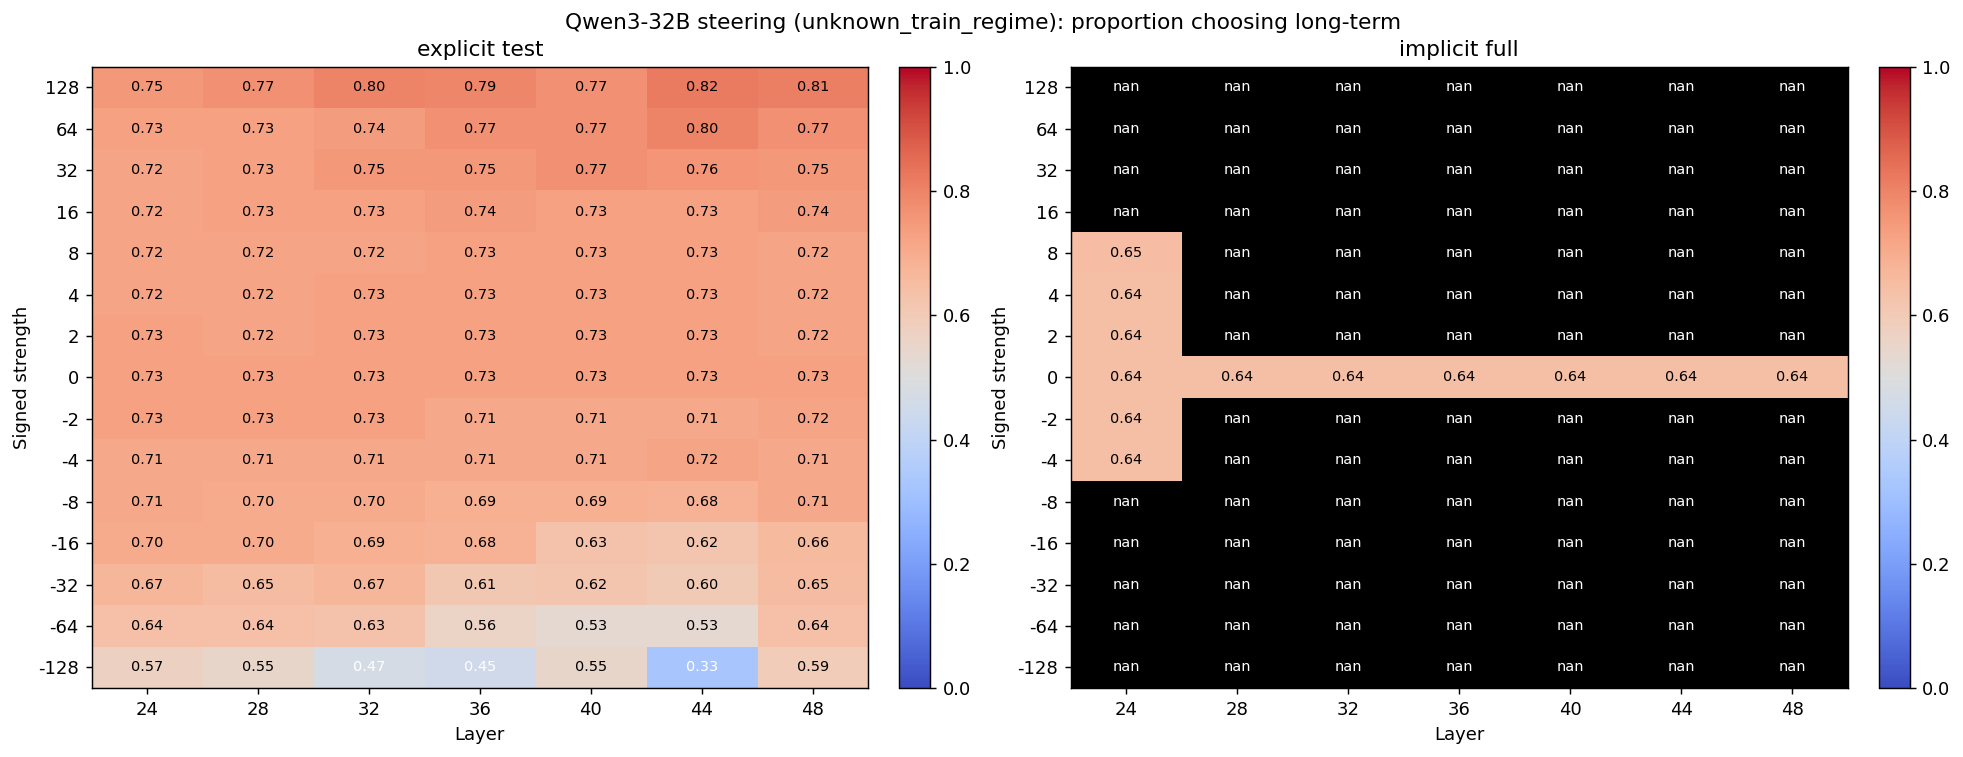

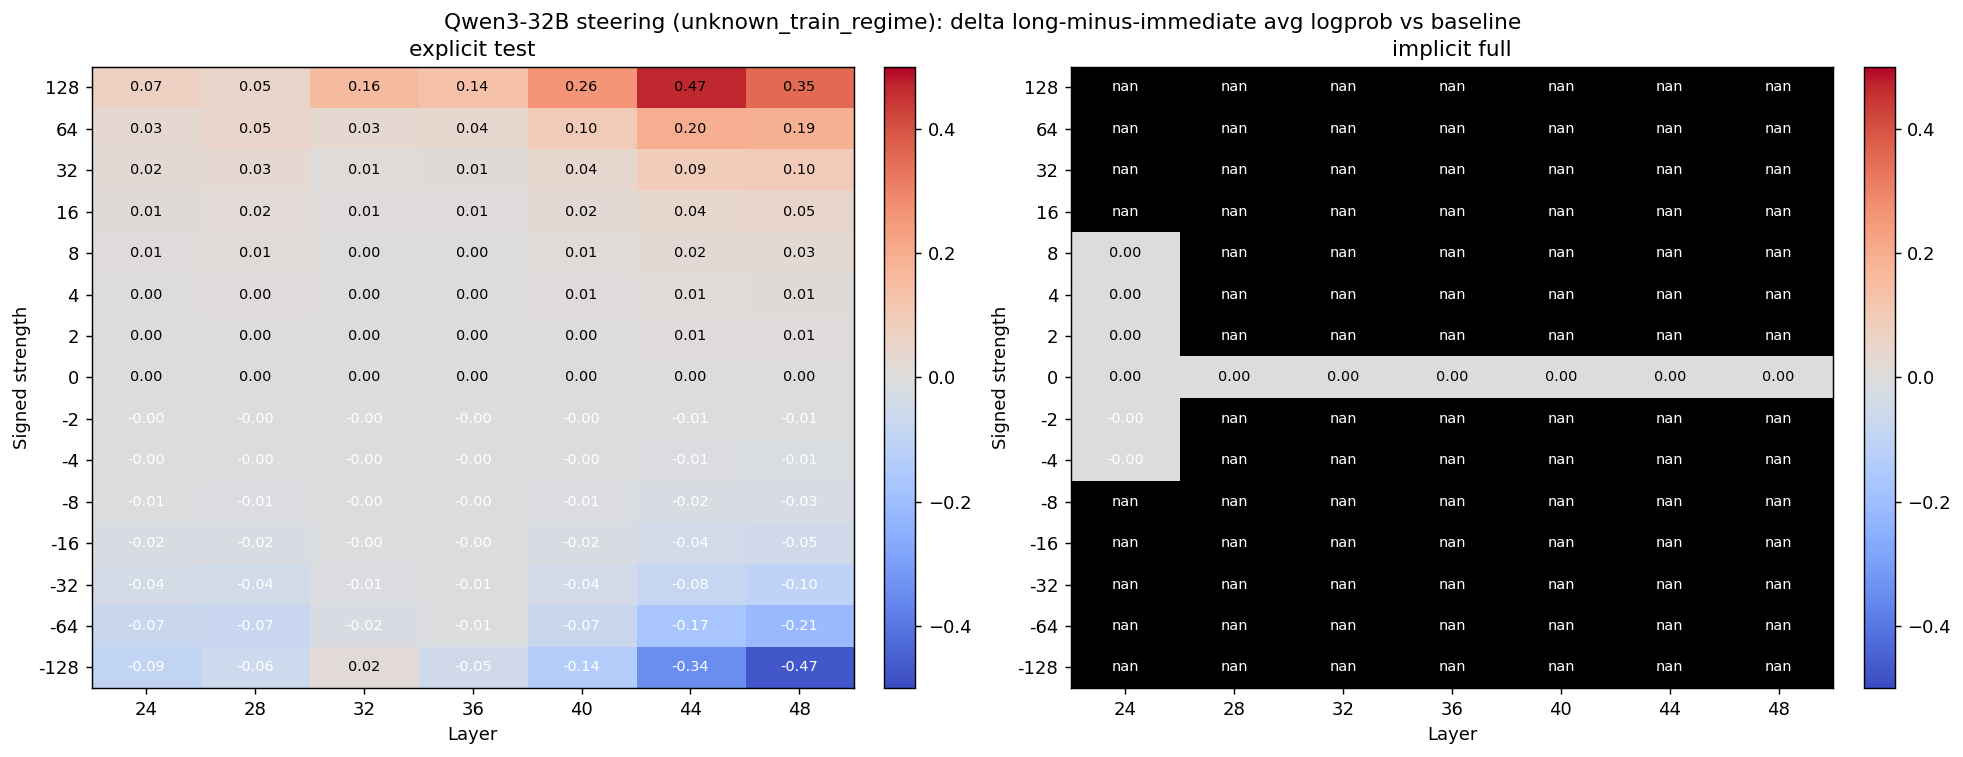

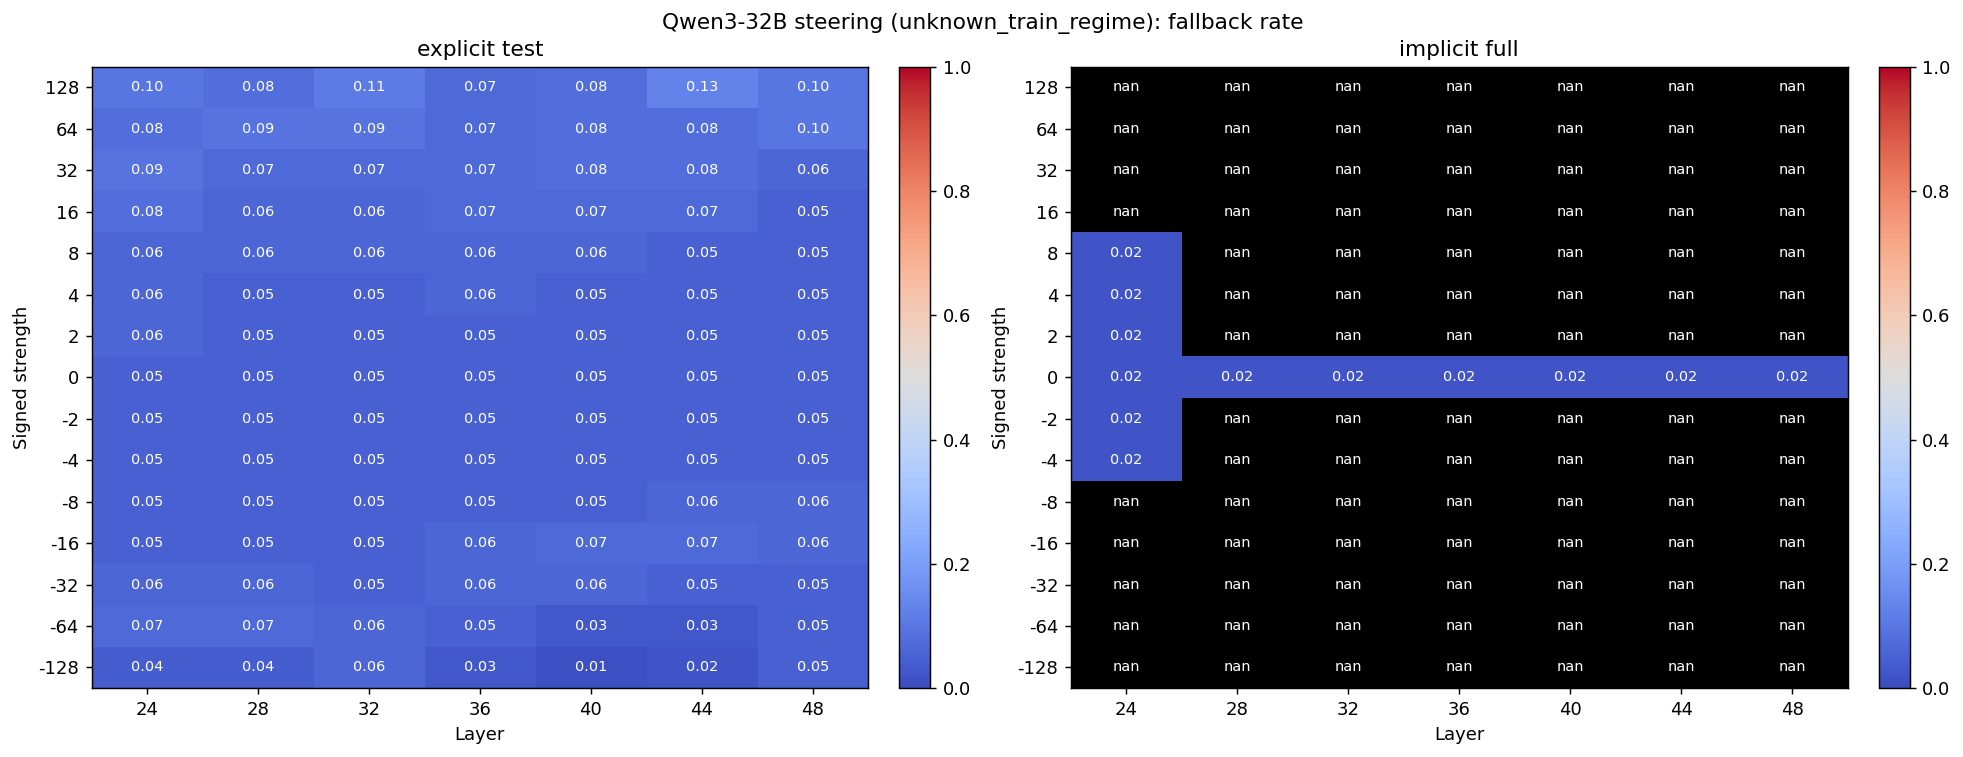

,metric_col,plot_path
0,prop_choose_long_term,/Users/michalmraz/code/spar-ai/temporal-awaren...
1,delta_long_minus_immediate_avg_logprob_vs_base...,/Users/michalmraz/code/spar-ai/temporal-awaren...
2,fallback_rate,/Users/michalmraz/code/spar-ai/temporal-awaren...


Saved plot index: /Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen3_32b/probe_artifact_steering_question_options_answer_vast/20260410-102655/replots_from_notebook/qwen3_32b_probe_steering_plot_index.csv


In [4]:
if not RUN_AVAILABLE:
    print('Skipping steering replots because no compatible run was found.')
else:
    model_name = config.get('model_name', 'Qwen3-32B')
    train_regime = config.get('train_regime', 'unknown_train_regime')
    plot_specs = [
        {
            'metric_col': 'prop_choose_long_term',
            'figure_title': f'{model_name} steering ({train_regime}): proportion choosing long-term',
            'output_name': 'qwen3_32b_probe_steering_prop_choose_long_term.png',
            'cmap': 'coolwarm',
            'vmin': 0.0,
            'vmax': 1.0,
            'range_mode': 'fixed',
        },
        {
            'metric_col': 'delta_long_minus_immediate_avg_logprob_vs_baseline',
            'figure_title': f'{model_name} steering ({train_regime}): delta long-minus-immediate avg logprob vs baseline',
            'output_name': 'qwen3_32b_probe_steering_delta_long_minus_immediate_avg_logprob_vs_baseline.png',
            'cmap': 'coolwarm',
            'vmin': -0.5,
            'vmax': 0.5,
            'range_mode': 'fixed',
        },
        {
            'metric_col': 'fallback_rate',
            'figure_title': f'{model_name} steering ({train_regime}): fallback rate',
            'output_name': 'qwen3_32b_probe_steering_fallback_rate.png',
            'cmap': 'coolwarm',
            'vmin': 0.0,
            'vmax': 1.0,
            'range_mode': 'fixed',
        },
    ]

    plot_index_rows = []
    for spec in plot_specs:
        output_path = plot_metric_grid(
            summary_df=summary_df,
            dataset_order=dataset_order,
            layer_order=layer_order,
            signed_strength_order=signed_strength_order,
            dataset_labels=dataset_labels,
            metric_col=spec['metric_col'],
            figure_title=spec['figure_title'],
            output_name=spec['output_name'],
            cmap=spec['cmap'],
            vmin=spec['vmin'],
            vmax=spec['vmax'],
            range_mode=spec['range_mode'],
        )
        plot_index_rows.append({'metric_col': spec['metric_col'], 'plot_path': str(output_path)})

    plot_index_df = pd.DataFrame(plot_index_rows)
    plot_index_path = PLOT_ROOT / 'qwen3_32b_probe_steering_plot_index.csv'
    plot_index_df.to_csv(plot_index_path, index=False)

    display(plot_index_df)
    print('Saved plot index:', plot_index_path)
